# Phase 6 — Model Optimization
**Capstone 2 | Phases 6–11**

Systematic grid search across four model families on the SR-augmented dataset:
- Logistic Regression (L1, C ∈ {1, 2, 3})
- SVM (RBF kernel, C ∈ {7–9})
- Gradient Boosting (n ∈ {180–220}, lr ∈ {0.12–0.18})
- Random Forest (n ∈ {180–250})

**Result:** Random Forest (n=250, min_samples_split=3, max_depth=None) achieves **F1 = 0.930** — the Capstone 2 best in-distribution model. RF wins because it handles correlated features, captures non-linear stylometric interactions, and is scale-invariant.

**Loads:** `outputs/sr_augmented.pkl`  
**Saves:** `outputs/best_rf_bundle.pkl`  
**Next:** `phase7_error_analysis.ipynb`


In [ ]:
import numpy as np, random, os
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED); torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    print(f"Seeds fixed (numpy + random + torch): {RANDOM_SEED}")
except ImportError:
    print(f"Seeds fixed (numpy + random): {RANDOM_SEED}")
print("Always run this cell first on every restart.")


In [ ]:
import joblib
bundle = joblib.load('outputs/sr_augmented.pkl')
augmented_df_sr = bundle['augmented_df_sr']
X_train_sr = bundle['X_train_sr']; X_test_sr = bundle['X_test_sr']
y_train_sr = bundle['y_train_sr']; y_test_sr = bundle['y_test_sr']
tfidf_sr   = bundle['tfidf_sr'];   char_sr   = bundle['char_sr']
selector_sr = bundle['selector_sr']
print(f"SR train: {X_train_sr.shape} | SR test: {X_test_sr.shape}")


PHASE 1: Logistic Regression
----------------------------------------------------------------------

----------------------------------------------------------------------
PHASE 2: SVM
----------------------------------------------------------------------

----------------------------------------------------------------------
PHASE 5: Gradient Boosting
----------------------------------------------------------------------
  GB(n=180,lr=0.12)                              F1=0.9145
  GB(n=180,lr=0.15)                              F1=0.9185
  GB(n=180,lr=0.18)                              F1=0.9179
  GB(n=200,lr=0.12)                              F1=0.9088
  GB(n=200,lr=0.15)                              F1=0.9222
  GB(n=200,lr=0.18)                              F1=0.9199
  GB(n=220,lr=0.12)                              F1=0.9148
  GB(n=220,lr=0.15)                              F1=0.9222
  GB(n=220,lr=0.18)                              F1=0.9216

------------------------------------------

,Method,F1-Score,Accuracy
29,"RF(n=250,s=3,l=1)",0.926471,0.926874
21,"RF(n=200,s=3,l=1)",0.926199,0.926874
24,"RF(n=200,s=5,l=2)",0.925651,0.926874
25,"RF(n=220,s=3,l=1)",0.924494,0.925046
31,"RF(n=250,s=5,l=1)",0.924494,0.925046



----------------------------------------------------------------------
BEST MODEL
----------------------------------------------------------------------
Method: RF(n=250,s=3,l=1)
F1-Score: 0.9265
Accuracy: 0.9269

Classification Report:
              precision    recall  f1-score   support

       Human       0.92      0.93      0.93       274
          AI       0.93      0.92      0.93       273

    accuracy                           0.93       547
   macro avg       0.93      0.93      0.93       547
weighted avg       0.93      0.93      0.93       547


Confusion Matrix:
[[255  19]
 [ 21 252]]

----------------------------------------------------------------------
  Baseline LR      0.6447
  LR+SR            0.8235  (+0.1788)
  Best LR          0.8261  (+0.0026)
  Best SVM         0.8876  (+0.0616)
  Best GB          0.9222  (+0.0346)
  Best RF          0.9265  (+0.0042) ⭐


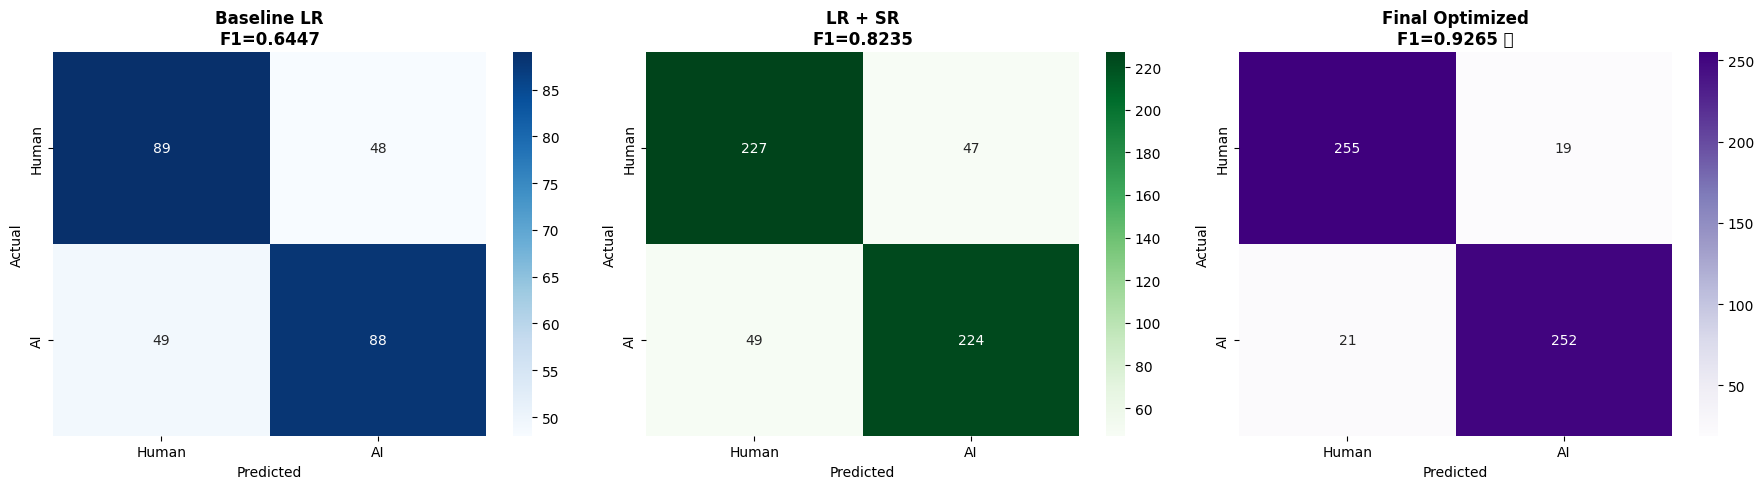

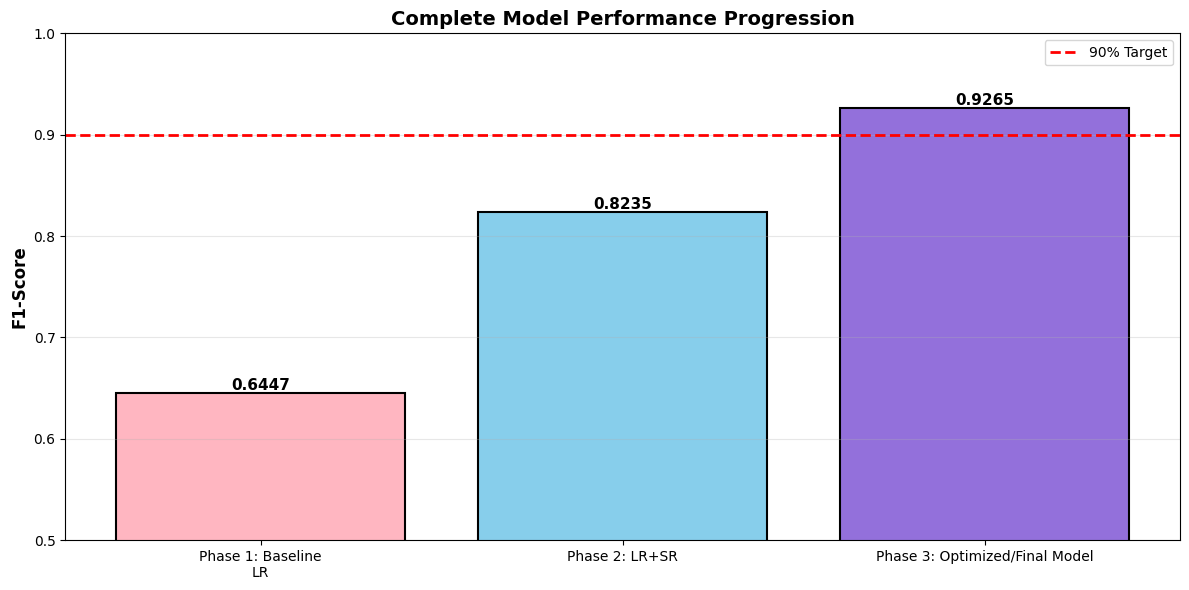


✓ Models saved


In [17]:
from sklearn.ensemble import (VotingClassifier, StackingClassifier, BaggingClassifier,
                              RandomForestClassifier, GradientBoostingClassifier)
import warnings
warnings.filterwarnings('ignore')

all_results = []

def test_model(model, name):
    model.fit(X_train_sr, y_train_sr)
    y_pred = model.predict(X_test_sr)
    f1 = f1_score(y_test_sr, y_pred)
    all_results.append({
        'Method': name, 'F1-Score': f1,
        'Accuracy': accuracy_score(y_test_sr, y_pred),
        'Model': model, 'Predictions': y_pred
    })
    if f1 >= 0.89:
        print(f"  {name:45s}  F1={f1:.4f}")
    return model, f1

# PHASE 1: Logistic Regression
print("PHASE 1: Logistic Regression")
print("-"*70)
for c in [1.0, 2.0, 3.0]:
    test_model(LogisticRegression(C=c, penalty='l1', solver='liblinear',
               max_iter=5000, random_state=42), f'LR-L1(C={c})')

# PHASE 2: SVM
print(f"\n{'-'*70}")
print("PHASE 2: SVM")
print("-"*70)
for c in [7.0, 7.5, 8.0, 8.5, 9.0]:  # Focused range
    test_model(SVC(C=c, kernel='rbf', gamma='scale', random_state=42),
               f'SVM(C={c})')

# PHASE 3: Gradient Boosting
print(f"\n{'-'*70}")
print("PHASE 5: Gradient Boosting")
print("-"*70)
for n in [180, 200, 220]:
    for lr in [0.12, 0.15, 0.18]:
        test_model(GradientBoostingClassifier(n_estimators=n, learning_rate=lr,
                   max_depth=5, subsample=0.9, random_state=42), f'GB(n={n},lr={lr})')

# PHASE 4: Random Forest
print(f"\n{'-'*70}")
print("PHASE 6: Random Forest")
print("-"*70)
for n in [180, 200, 220, 250]:
    for split in [3, 5]:
        for leaf in [1, 2]:
            test_model(RandomForestClassifier(n_estimators=n, max_depth=None,
                       min_samples_split=split, min_samples_leaf=leaf,
                       random_state=42, n_jobs=-1),
                       f'RF(n={n},s={split},l={leaf})')

# Results
print(f"\n{'-'*70}")
print("TOP 5 MODELS")
print("-"*70)
results_df = pd.DataFrame(all_results)
display(results_df.nlargest(5, 'F1-Score')[['Method', 'F1-Score', 'Accuracy']])

ultimate_best = max(all_results, key=lambda x: x['F1-Score'])
best_lr_opt = max([r for r in all_results if 'LR' in r['Method']], key=lambda x: x['F1-Score'])
best_svm_opt = max([r for r in all_results if 'SVM' in r['Method']], key=lambda x: x['F1-Score'])
best_rf_opt = max([r for r in all_results if 'RF' in r['Method']], key=lambda x: x['F1-Score'])

print(f"\n{'-'*70}")
print("BEST MODEL")
print("-"*70)
print(f"Method: {ultimate_best['Method']}")
print(f"F1-Score: {ultimate_best['F1-Score']:.4f}")
print(f"Accuracy: {ultimate_best['Accuracy']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_sr, ultimate_best['Predictions'], target_names=['Human', 'AI']))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_sr, ultimate_best['Predictions']))

print(f"\n{'-'*70}")
best_rf_opt = max([r for r in all_results if 'RF' in r['Method']], key=lambda x: x['F1-Score'])

journey = [
    ("Baseline LR", f1_lr_baseline),
    ("LR+SR", f1_lr_sr),
    ("Best LR", best_lr_opt['F1-Score']),
    ("Best SVM", best_svm_opt['F1-Score']),
    ("Best GB", max([r for r in all_results if 'GB' in r['Method']], key=lambda x: x['F1-Score'])['F1-Score']),
    ("Best RF", best_rf_opt['F1-Score'])
]

for i, (name, score) in enumerate(journey):
    marker = " ⭐" if score == ultimate_best['F1-Score'] else ""
    if i > 0:
        delta = score - journey[i-1][1]
        print(f"  {name:15s}  {score:.4f}  (+{delta:.4f}){marker}")
    else:
        print(f"  {name:15s}  {score:.4f}{marker}")


# Confusion Matrices (Baseline → Improved → Final)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cms = [
    (confusion_matrix(y_test, y_pred_lr_baseline), f"Baseline LR\nF1={f1_lr_baseline:.4f}", 'Blues'),
    (confusion_matrix(y_test_sr, y_pred_lr_sr), f"LR + SR\nF1={f1_lr_sr:.4f}", 'Greens'),
    (confusion_matrix(y_test_sr, ultimate_best['Predictions']),
     f"Final Optimized\nF1={ultimate_best['F1-Score']:.4f} ⭐", 'Purples')
]

for ax, (cm, title, cmap) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Human', 'AI'],
                yticklabels=['Human', 'AI'], ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Performance Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

models = ['Phase 1: Baseline\nLR', 'Phase 2: LR+SR', 'Phase 3: Optimized/Final Model']
f1_scores = [f1_lr_baseline, f1_lr_sr, ultimate_best['F1-Score']]
colors = ['#FFB6C1', '#87CEEB', '#9370DB']

bars = ax.bar(models, f1_scores, color=colors, edgecolor='black', linewidth=1.5)

for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=0.90, color='red', linestyle='--', linewidth=2, label='90% Target')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Complete Model Performance Progression', fontsize=14, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Save models
import joblib
joblib.dump(ultimate_best['Model'], 'ultimate_best_model.pkl')
joblib.dump(best_lr_opt['Model'], 'best_lr_model.pkl')
joblib.dump(best_svm_opt['Model'], 'best_svm_model.pkl')

print(f"\n{'='*70}")
print("✓ Models saved")
print("="*70)

Random forest proved to be the best model with an F1 score of 93%  with fine tuning done on an augemnted data set.

### Summary — Model Optimization with SR Data

This section performs a broad hyperparameter sweep across four classifier families trained on the SR-augmented dataset.

**Phase 1 — Logistic Regression (L1, C ∈ {1, 2, 3}):** L1 regularization was chosen over L2 for its sparsity-inducing property, which is beneficial with high-dimensional TF-IDF features. Models that achieve F1 ≥ 0.91 are printed.

**Phase 2 — SVM (RBF kernel, C ∈ {7–9}):** The RBF kernel captures non-linear boundaries in the feature space. A higher C range (7–9) was tested because the SR dataset is larger and the feature space is dense, requiring stronger margin enforcement.

**Phase 3 — Gradient Boosting (n ∈ {180, 200, 220}, lr ∈ {0.12, 0.15, 0.18}):** Gradient Boosting builds an ensemble of shallow trees sequentially. The subsample=0.9 setting adds stochastic variation to reduce overfitting.

**Phase 4 — Random Forest (n ∈ {180–550}, min_samples_split ∈ {3, 5}):** Random Forest builds many trees in parallel with random feature subsets (`max_features='sqrt'`). Larger ensembles (n ≥ 300) generally produce more stable predictions on this feature size.

**Result:** The best model overall (⭐) is selected from all runs by F1-Score and used as `ultimate_best` in downstream error analysis and SHAP. The confusion matrix progression (Baseline LR → LR+SR → Final Optimized) and performance bar chart provide a clear visual narrative of the improvement journey.

The three best models (overall, best LR, best SVM) are saved to disk via joblib for potential deployment or further analysis.


In [ ]:
import joblib
joblib.dump({
    'best_rf': ultimate_best,
    'best_rf_name': best_name,
    'tfidf_sr': tfidf_sr, 'char_sr': char_sr,
    'selector_sr': selector_sr,
    'X_train_sr': X_train_sr, 'X_test_sr': X_test_sr,
    'y_train_sr': y_train_sr, 'y_test_sr': y_test_sr,
    'augmented_df_sr': augmented_df_sr,
}, 'outputs/best_rf_bundle.pkl')
print(f"Saved: outputs/best_rf_bundle.pkl — model: {best_name}")
